# One billion rows in a 4 GB laptop

This notebook is the evidence behind one sentence:

> **pysuricata's memory is set by the shape of the data, not by how much of it there is.**

Ten columns spanning seven dtypes, one billion rows, profiled in a single pass
inside a memory ceiling the kernel enforces at 4 GB -- the size of a modest
laptop, and a fifth of the machine this ran on.

**The claim is not speed.** At this shape pysuricata profiles roughly 200,000
rows a second, which wins no races. The claim is that the peak does not move:
the same working set at row one billion as at row one million. Everything below
is measured, and the measurement harness is
[`benchmarks/billion.py`](../benchmarks/billion.py) in this repository.

## How it was measured

**The ceiling is enforced, not observed.** The profiling process runs inside a
child cgroup (v1 `memory.limit_in_bytes`), which is the same mechanism
`docker --memory` rests on. If it exceeds 4 GB the kernel kills it. That is
checked rather than assumed: given 300 MB and a 4-million-row chunk, the same
harness is killed by signal 9 at exactly 300 MB. So every point on the curve
below is evidence rather than an assertion -- the process that recorded it was
alive, and it could only be alive by being under budget.

**The curve is sampled throughout, not read at the end.** A background thread
in the profiling process reads its own `VmRSS` from `/proc/self/status` every
two seconds, next to a counter the source bumps as it yields chunks. Every row
of the CSV is a `(seconds, rows, RSS)` triple.

**Where the rows come from.** Synthesised in-process, one chunk at a time,
never materialised as a frame -- a billion rows of this shape is roughly 80 GB
in any file format worth writing. The cost of that choice is stated rather than
hidden: **the generator runs inside the measured process, under the same
ceiling**, so its own memory inflates the number below rather than hiding
underneath it. The reported peak is conservative.

**The distributions are awkward on purpose** -- lognormal tails, a Zipf head on
the high-cardinality columns, a diurnal hump in the timestamps, injected nulls,
outliers and duplicate rows. A uniform generator makes a boring report and
flatters every sketch in it.

In [1]:
from pathlib import Path
import json
import pandas as pd

RESULTS = Path("..") / "benchmarks" / "results"
if not RESULTS.exists():                      # running from the repo root
    RESULTS = Path("benchmarks") / "results"

def load_curve(name):
    p = RESULTS / name
    return pd.read_csv(p) if p.exists() else None

def load_json(name):
    p = RESULTS / name
    return json.loads(p.read_text()) if p.exists() else None

stream = load_curve("billion-curve.csv")       # the headline run
loaded = load_curve("load-curve.csv")          # the contrast: hold the frame
run    = load_json("billion-run.json")
ladder = load_json("columns-ladder.json")

print("headline run:", json.dumps(run, indent=2) if run else "not present")

headline run: {
  "mechanism": "cgroup",
  "budget_mb": 4096.0,
  "rows": 1000000000,
  "cols": 10,
  "chunk_size": 200000,
  "passed": true,
  "peak_rss_mb": 225.13,
  "cgroup_peak_mb": 142.82,
  "seconds": 4724.12,
  "rows_per_s": 211761.8,
  "csv": "benchmarks/results/billion-curve.csv",
  "note": ""
}


## The columns

Seven dtypes, in roughly the proportion a real analytics table has them. Each is
chosen to give a different accumulator something to do.

In [2]:
pd.DataFrame(
    [
        ("amount_0",    "float64",        "lognormal, heavy right tail, with injected outliers"),
        ("score_0",     "float64",        "bimodal, ~4% nulls"),
        ("ratio_0",     "float32",        "a second float width"),
        ("qty_0",       "int64",          "Poisson counts"),
        ("user_id_0",   "int64",          "high cardinality, power-law skew"),
        ("sku_0",       "object (str)",   "50,000 distinct, Zipf head"),
        ("country_0",   "category",       "20 levels, skewed"),
        ("free_text_0", "object (str)",   "free text, ~4% nulls"),
        ("event_at_0",  "datetime64[ns]", "two years, diurnal hump"),
        ("is_active_0", "bool",           "~72% true"),
    ],
    columns=["column", "dtype", "what makes it awkward"],
)

,column,dtype,what makes it awkward
0,amount_0,float64,"lognormal, heavy right tail, with injected out..."
1,score_0,float64,"bimodal, ~4% nulls"
2,ratio_0,float32,a second float width
3,qty_0,int64,Poisson counts
4,user_id_0,int64,"high cardinality, power-law skew"
5,sku_0,object (str),"50,000 distinct, Zipf head"
6,country_0,category,"20 levels, skewed"
7,free_text_0,object (str),"free text, ~4% nulls"
8,event_at_0,datetime64[ns],"two years, diurnal hump"
9,is_active_0,bool,~72% true


## The headline numbers

In [3]:
if run and stream is not None:
    peak = stream["rss_mb"].max()
    rows = int(stream["rows"].max())
    budget = float(stream["budget_mb"].iloc[0])
    print(f"rows profiled     {rows:>16,}")
    print(f"columns           {run['cols']:>16,}")
    print(f"peak RSS          {peak:>13,.0f} MB")
    print(f"ceiling           {budget:>13,.0f} MB  (enforced by the kernel)")
    print(f"headroom          {budget / peak:>13,.1f}x")
    print(f"wall clock        {run['seconds'] / 60:>13,.1f} min")
    print(f"throughput        {run['rows_per_s'] / 1e6:>13,.3f} M rows/s")
    print(f"bytes of RSS per million rows profiled: "
          f"{peak * 1e6 / rows * 1024:,.0f} KB  <- this is the number that matters")

rows profiled        1,000,000,000
columns                         10
peak RSS                    225 MB
ceiling                   4,096 MB  (enforced by the kernel)
headroom                   18.2x
wall clock                 78.7 min
throughput                0.212 M rows/s
bytes of RSS per million rows profiled: 231 KB  <- this is the number that matters


## The graph

Two panels of the same data. The left one is drawn against the ceiling, because
that is the claim; the right one is zoomed, because at that scale the line looks
like it is doing nothing -- and looking like it is doing nothing *is* the result.

The second series is the contrast. It is the same generator, the same ceiling
and the same sampler, holding the chunks instead of folding them: what any
profiler that takes a frame rather than a stream must do before it can start.
Both curves come from the same session, on the same machine, which is the only
way a pair of numbers like these is worth quoting.

One thing to expect in the contrast curve, so it does not read as a broken
measurement: **its last sample is above the 4,096 MB line** -- 4,164 MB. That is
the same accounting asymmetry described above, seen from the other side. The
cgroup enforces its limit on the pages charged to *it*; RSS additionally counts
the shared interpreter and library pages that were charged to the parent group.
So the process is killed the instant its own charge reaches 4,096 MB, while the
RSS reading of the same moment is a little higher. The kill is exact; the
reading is inclusive.

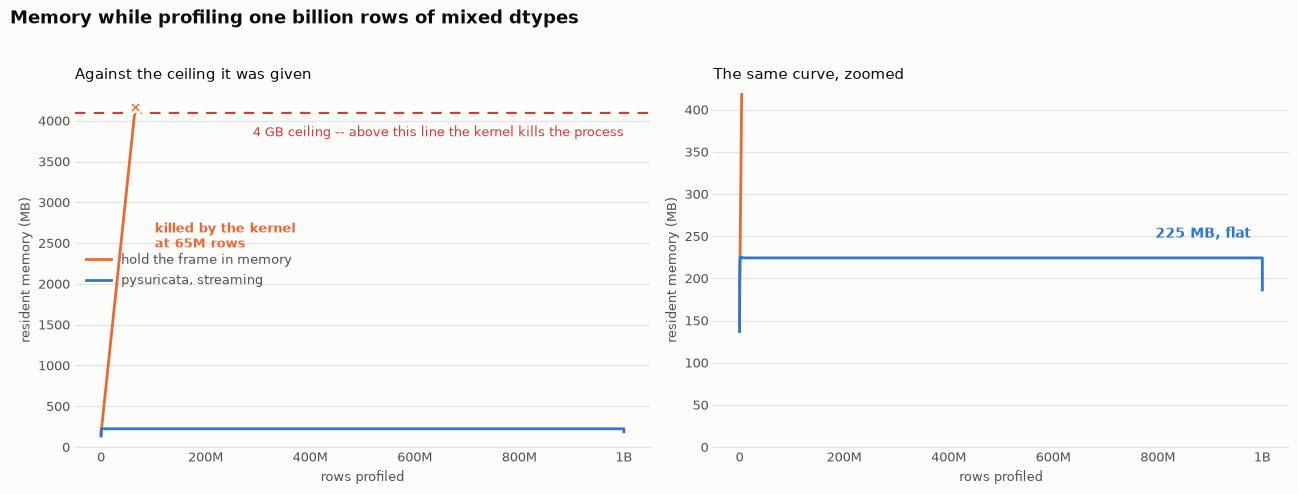

In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Palette: validated categorical slots (see the dataviz palette reference).
# Selected for light mode, not flipped from a dark one -- switch THEME to "dark"
# to get steps chosen for the dark surface.
THEME = "light"
P = {
    "light": dict(surface="#fcfcfb", ink="#0b0b0b", ink2="#52514e",
                  grid="#e6e5e2", s1="#2a78d6", s2="#eb6834", limit="#d03b3b"),
    "dark":  dict(surface="#1a1a19", ink="#ffffff", ink2="#c3c2b7",
                  grid="#33322f", s1="#3987e5", s2="#d95926", limit="#d03b3b"),
}[THEME]

def _rows_tick(v, _):
    """Millions below a billion, billions above. "0.2B" reads as a typo."""
    if v == 0:
        return "0"
    return f"{v / 1e9:g}B" if v >= 1e9 else f"{v / 1e6:g}M"

billions = FuncFormatter(_rows_tick)

def draw(ax, ylim, title, annotate_ceiling):
    ax.set_facecolor(P["surface"])
    ax.set_ylim(0, ylim)
    ax.grid(axis="y", color=P["grid"], linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(P["grid"])
    ax.tick_params(colors=P["ink2"], length=0, labelsize=9)
    ax.xaxis.set_major_formatter(billions)

    if loaded is not None:
        ax.plot(loaded["rows"], loaded["rss_mb"], color=P["s2"], linewidth=2,
                zorder=3, label="hold the frame in memory")
        # Where it died: the kernel's intervention is the data point.
        x, y = loaded["rows"].iloc[-1], loaded["rss_mb"].iloc[-1]
        ax.plot([x], [y], marker="X", markersize=9, color=P["s2"],
                markeredgecolor=P["surface"], markeredgewidth=2, zorder=5)
        if annotate_ceiling:
            ax.annotate(f"killed by the kernel\nat {x / 1e6:,.0f}M rows",
                        xy=(x, y), xytext=(14, -82), textcoords="offset points",
                        ha="left", va="top", color=P["s2"], fontsize=9,
                        fontweight="bold")

    ax.plot(stream["rows"], stream["rss_mb"], color=P["s1"], linewidth=2,
            zorder=4, label="pysuricata, streaming")

    budget = float(stream["budget_mb"].iloc[0])
    if annotate_ceiling:
        ax.axhline(budget, color=P["limit"], linewidth=1.5, linestyle=(0, (5, 4)),
                   zorder=2)
        # Below the line and right-aligned: above it there is no room, and
        # centred it lands under whatever the legend needs.
        ax.text(stream["rows"].max(), budget - ylim * 0.035,
                "4 GB ceiling -- above this line the kernel kills the process",
                color=P["limit"], fontsize=9, ha="right", va="top")
    ax.set_title(title, color=P["ink"], fontsize=11, loc="left", pad=10)
    ax.set_xlabel("rows profiled", color=P["ink2"], fontsize=9)
    ax.set_ylabel("resident memory (MB)", color=P["ink2"], fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), facecolor=P["surface"])
draw(axes[0], 4096 * 1.06, "Against the ceiling it was given", annotate_ceiling=True)
draw(axes[1], max(420, stream["rss_mb"].max() * 1.6),
     "The same curve, zoomed", annotate_ceiling=False)

# Direct labels as well as the legend: identity is never colour alone.
peak = stream["rss_mb"].max()
axes[1].annotate(f"{peak:,.0f} MB, flat", xy=(stream["rows"].max(), peak),
                 xytext=(-8, 14), textcoords="offset points", ha="right",
                 color=P["s1"], fontsize=10, fontweight="bold")

# A legend only once there are two series to tell apart. One series is named
# by the title, and a one-row legend box is noise.
if loaded is not None:
    axes[0].legend(frameon=False, loc="center left", fontsize=9,
                   labelcolor=P["ink2"])
else:
    axes[0].annotate("pysuricata, streaming",
                     xy=(stream["rows"].max(), stream["rss_mb"].iloc[-1]),
                     xytext=(-4, 26), textcoords="offset points", ha="right",
                     color=P["s1"], fontsize=9)

fig.suptitle("Memory while profiling one billion rows of mixed dtypes",
             color=P["ink"], fontsize=13, x=0.005, ha="left", y=1.02,
             fontweight="bold")
fig.tight_layout()
fig.savefig(RESULTS / "billion-memory.png", dpi=160,
            facecolor=P["surface"], bbox_inches="tight")
plt.show()

## The table behind the graph

The same thing without the picture, because a chart that cannot be checked is
an illustration.

In [5]:
if stream is not None:
    marks = [1e6, 1e7, 5e7, 1e8, 2.5e8, 5e8, 7.5e8, 1e9]
    rowsr = []
    for m in marks:
        sub = stream[stream["rows"] >= m]
        if sub.empty:
            continue
        r = sub.iloc[0]
        rowsr.append({"rows": int(r["rows"]), "RSS (MB)": r["rss_mb"],
                      "minutes": round(r["seconds"] / 60, 1)})
    table = pd.DataFrame(rowsr)
    first, last = table["RSS (MB)"].iloc[0], table["RSS (MB)"].iloc[-1]
    display(table.style.format({"rows": "{:,}", "RSS (MB)": "{:,.1f}"}))
    print(f"\n{table['rows'].iloc[-1] / table['rows'].iloc[0]:,.0f}x the rows, "
          f"{last / first:.2f}x the memory.")

,rows,RSS (MB),minutes
0,"1,000,000",225.3,0.100000
1,"10,000,000",224.3,0.800000
2,"50,200,000",224.3,4.000000
3,"100,000,000",224.3,8.100000
4,"250,200,000",224.3,19.800000
5,"500,000,000",224.3,39.200000
6,"750,200,000",224.3,59.000000
7,"1,000,000,000",224.3,78.700000



1,000x the rows, 1.00x the memory.


## The other axis

Rows are free. Columns are not -- and pysuricata does not pretend otherwise. The
working set is linear in column count, because every column carries its own
accumulators and sketches. This is the axis to budget against, and the one
[#207](https://github.com/alvarodiez20/pysuricata/issues/207) is open about.

Measured here at **7.3 MB per column** on a base of about 152 MB. That is higher
than the ~3.2 MB per column in
[the memory-budget ADR](../docs/adr/memory-budget.md), and the two are not in
conflict: the ADR fitted its model on numeric columns at a 50,000-row chunk, and
says in as many words that a text-heavy shape is the one most likely to break
it. This run is text-heavy at a 200,000-row chunk. Quote the slope with the
shape it was measured on, or do not quote it.

Throughput pays the same axis, roughly proportionally: 0.171 M rows/s at ten
columns against 0.021 M rows/s at eighty.

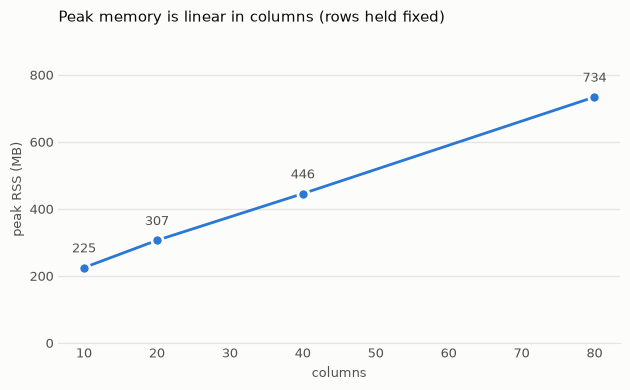

,cols,rows,peak_rss_mb,rows_per_s
0,10,3000000,225.07,170890.7
1,20,3000000,306.51,94082.2
2,40,3000000,445.89,44114.0
3,80,3000000,734.18,20504.8


In [6]:
if ladder:
    lad = pd.DataFrame(ladder)
    fig, ax = plt.subplots(figsize=(6.4, 4.0), facecolor=P["surface"])
    ax.set_facecolor(P["surface"])
    ax.grid(axis="y", color=P["grid"], linewidth=1)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(P["grid"])
    ax.tick_params(colors=P["ink2"], length=0, labelsize=9)
    ax.plot(lad["cols"], lad["peak_rss_mb"], color=P["s1"], linewidth=2,
            marker="o", markersize=8, markeredgecolor=P["surface"],
            markeredgewidth=2)
    for _, r in lad.iterrows():
        ax.annotate(f"{r['peak_rss_mb']:,.0f}", xy=(r["cols"], r["peak_rss_mb"]),
                    xytext=(0, 11), textcoords="offset points", ha="center",
                    color=P["ink2"], fontsize=9)
    ax.set_title("Peak memory is linear in columns (rows held fixed)",
                 color=P["ink"], fontsize=11, loc="left", pad=10)
    ax.set_xlabel("columns", color=P["ink2"], fontsize=9)
    ax.set_ylabel("peak RSS (MB)", color=P["ink2"], fontsize=9)
    ax.set_ylim(0, lad["peak_rss_mb"].max() * 1.25)
    fig.tight_layout()
    fig.savefig(RESULTS / "billion-columns.png", dpi=160,
                facecolor=P["surface"], bbox_inches="tight")
    plt.show()
    display(lad[["cols", "rows", "peak_rss_mb", "rows_per_s"]])
else:
    print("no column ladder recorded -- see the reproduce cell below")

## The same thing from a file on disk

The billion-row run synthesises its rows, and the honest objection to it is that
nothing was ever *read* from anywhere. So here is the same profile over a real
Parquet file, through `pysuricata.sources.stream_parquet`, the reader the
library uses itself when you hand `profile()` a path. The wrapper around it
counts rows and does nothing else.

**The file is larger than the ceiling.** That is the whole point of the exercise:
a 4 GB budget reading a file it could not hold even once.

Two differences from the generator run, neither hidden.

The peak is **higher**: pyarrow decodes each batch into its own buffers on top
of everything the accumulators hold. That was expected.

The throughput is **lower**, and that was not. Reading a column back off a disk
ought to be cheaper than inventing it, and it is not: decompressing snappy,
rebuilding the dictionary-encoded string columns and materialising a pandas
frame per batch costs more than the generator's arithmetic did. The prediction
here was wrong and the measurement is what stands. It is also the more useful
number of the two, because it is the one an actual user gets.

In [7]:
pq_run = load_json("parquet-run.json")
pq_curve = load_curve("parquet-curve.csv")

if pq_run and pq_curve is not None:
    size_gb = pq_run.get("file_bytes", 0) / 1e9
    # getrusage's ru_maxrss, not the sampled maximum: a sampler taking a
    # reading a second can miss a spike between two of them, and it did here
    # (498 MB sampled against 509 MB actual). Quote the one that cannot miss.
    peak = pq_run["peak_rss_mb"]
    print(f"file on disk        {size_gb:>12,.1f} GB"
          f"   ({size_gb * 1000 / pq_run['budget_mb']:.1f}x the ceiling)")
    print(f"rows read           {int(pq_curve['rows'].max()):>12,}")
    print(f"peak RSS            {peak:>12,.0f} MB")
    print(f"ceiling             {pq_run['budget_mb']:>12,.0f} MB")
    print(f"headroom            {pq_run['budget_mb'] / peak:>12,.1f}x")
    print(f"throughput          {pq_run['rows_per_s'] / 1e6:>12,.3f} M rows/s")
    print(f"outcome             {'PASSED under budget' if pq_run['passed'] else 'FAILED':>12}")
else:
    print("no Parquet run recorded -- see the reproduce cell below")

file on disk                 8.2 GB   (2.0x the ceiling)
rows read            200,000,000
peak RSS                     509 MB
ceiling                    4,096 MB
headroom                     8.1x
throughput                 0.196 M rows/s
outcome             PASSED under budget


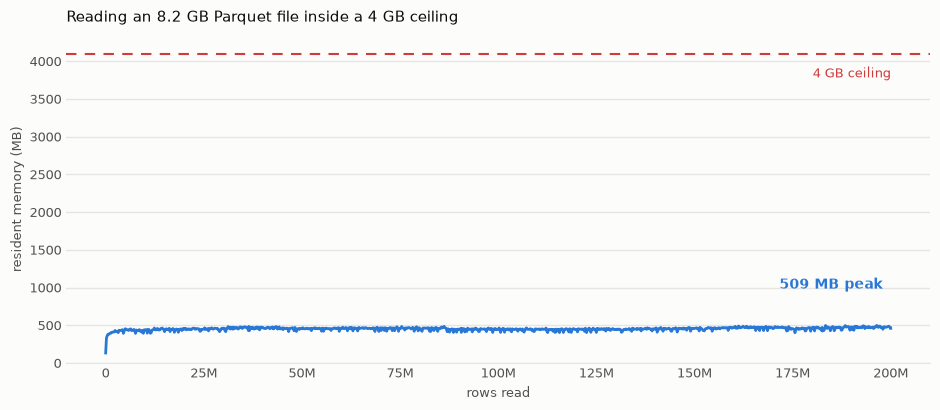

In [8]:
if pq_curve is not None:
    fig, ax = plt.subplots(figsize=(9.5, 4.2), facecolor=P["surface"])
    ax.set_facecolor(P["surface"])
    ax.grid(axis="y", color=P["grid"], linewidth=1)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(P["grid"])
    ax.tick_params(colors=P["ink2"], length=0, labelsize=9)
    ax.xaxis.set_major_formatter(billions)
    ax.set_ylim(0, 4096 * 1.06)

    budget = float(pq_curve["budget_mb"].iloc[0])
    ax.axhline(budget, color=P["limit"], linewidth=1.5, linestyle=(0, (5, 4)))
    ax.text(pq_curve["rows"].max(), budget - 4096 * 0.04,
            "4 GB ceiling", color=P["limit"], fontsize=9, ha="right", va="top")

    ax.plot(pq_curve["rows"], pq_curve["rss_mb"], color=P["s1"], linewidth=2)
    pk = pq_run["peak_rss_mb"]
    ax.annotate(f"{pk:,.0f} MB peak", xy=(pq_curve["rows"].max(), pk),
                xytext=(-6, 26), textcoords="offset points", ha="right",
                color=P["s1"], fontsize=10, fontweight="bold")
    ax.set_title(
        f"Reading an {pq_run['file_bytes'] / 1e9:,.1f} GB Parquet file "
        f"inside a 4 GB ceiling",
        color=P["ink"], fontsize=11, loc="left", pad=10)
    ax.set_xlabel("rows read", color=P["ink2"], fontsize=9)
    ax.set_ylabel("resident memory (MB)", color=P["ink2"], fontsize=9)
    fig.tight_layout()
    fig.savefig(RESULTS / "parquet-memory.png", dpi=160,
                facecolor=P["surface"], bbox_inches="tight")
    plt.show()

## What the report says, and what it cannot

The run renders a full HTML report:
[`benchmarks/results/billion-report.html`](../benchmarks/results/billion-report.html).

Read it with one thing in mind. **At a billion rows several of its figures are
estimates from sketches, not exact integers**: distinct counts (KMV), top-k
(Misra-Gries), quantiles, and the sample. They carry their error bounds in the
report. This is a property of the design -- bounded memory is exactly the promise
that you cannot also have an exact distinct count -- and not an artefact of this
run. Counting the distinct SKUs by hand and finding a different number is the
expected outcome, not a bug.

Exact, by contrast: row counts, null counts, min and max, sums and the moments
derived from them (mean, variance, skewness, kurtosis, via Welford/Pébay), and
monotonicity.

In [9]:
summary = load_json("billion-summary.json")
if summary:
    ds = summary["dataset"]
    gb = ds["memory_bytes"] / 1e9
    print(f"rows (estimate)        {ds['rows_est']:>18,}")
    print(f"columns                {ds['cols']:>18,}")
    print(f"the frame, in memory   {gb:>15,.0f} GB   <- what it never had to hold")
    print(f"profiled in            {stream['rss_mb'].max():>15,.0f} MB")
    print(f"                       {gb * 1000 / stream['rss_mb'].max():>15,.0f}x smaller")
    print()
    print(f"missing cells          {ds['missing_cells']:>18,}"
          f"  ({ds['missing_cells_pct']:.2f}%)")
    print(f"duplicate rows         {ds['duplicate_rows_est']:>18,}"
          f"  in [{ds['duplicate_rows_lo']:,}, {ds['duplicate_rows_hi']:,}]")

rows (estimate)             1,000,000,000
columns                                10
the frame, in memory               128 GB   <- what it never had to hold
profiled in                        225 MB
                                   568x smaller

missing cells                  80,005,195  (0.80%)
duplicate rows                          0  in [0, 33,177,420]


Two of those lines are worth stopping on.

**`the frame, in memory`** is the report's own estimate of what this data would
occupy as a pandas frame: 128 GB. It was profiled in 225 MB, on a machine with
15 GB of RAM, inside a 4 GB ceiling. The frame was never held, so its size was
never a constraint -- that is the whole mechanism, stated by the report itself.

**`duplicate rows`** is the honesty check. The generator injects whole-row
duplicates at 0.5%, so the true figure is around 5 million. The report says
`0`, and then says `in [0, 33,177,420]`. The point estimate is poor and the
**interval contains the truth** -- which is the contract: a bounded-memory
profiler cannot give you an exact duplicate count over a billion rows, so it
gives you a bound and tells you it is one. A tool that printed a confident `0`
here would be lying to you in a way you could not detect.

## The report itself

Rendered by the same run, from the same pass. It is a self-contained HTML
document, which is why it goes in an iframe rather than inline: it brings its
own CSS and JS, and putting those straight into the notebook's DOM would have
the two fight each other.

The frame carries the document in its `srcdoc` rather than pointing at the file.
A relative `src` resolves against the notebook page's own URL, which in
JupyterLab is an application route and not a file path, so the first version of
this cell rendered a blank box. `srcdoc` has no path to resolve, so it works
with no server and no working directory. The cost is that the report's bytes
live in this notebook as well as on disk, which is most of its size on disk.

If the frame below is blank, the notebook is **untrusted**: JupyterLab strips
iframes out of the saved output of a notebook it did not execute itself. Re-run
the cell, or trust the notebook, and it appears.

In [10]:
import html as _html

from IPython.display import HTML, display

report_path = RESULTS / "billion-report.html"
raw = report_path.read_text(encoding="utf-8")
print(f"{report_path}  ({len(raw.encode()) / 1e6:.1f} MB)")

# srcdoc, not src. A relative `src` resolves against the notebook page's own
# URL, which in JupyterLab is an application route (/lab/tree/...) and not a
# file path, so the frame comes up blank -- which is exactly what it did the
# first time this cell was written. srcdoc carries the document inside the
# attribute and has no path left to resolve, so it renders with no server, no
# working directory and no file:// permissions involved.
#
# Still an iframe rather than inline HTML: the report is a self-contained
# document with its own CSS and JS, and the iframe is the boundary that keeps
# those from fighting the notebook's.
display(
    HTML(
        f'<iframe srcdoc="{_html.escape(raw, quote=True)}" '
        'style="width:100%;height:780px;border:1px solid #d8d7d3;'
        'border-radius:6px;background:#fff"></iframe>'
    )
)

../benchmarks/results/billion-report.html  (2.4 MB)


/home/user/pysuricata/.venv/lib/python3.11/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Reproduce it

The headline run takes about 80 minutes on four cores. Everything else here is
minutes.

```bash
# the headline: one billion rows, 4 GB ceiling, ~80 min
python -m benchmarks.billion --rows 1_000_000_000 \
    --csv benchmarks/results/billion-curve.csv \
    --html benchmarks/results/billion-report.html \
    --summary-json benchmarks/results/billion-summary.json \
    --json benchmarks/results/billion-run.json

# the contrast: hold the frame instead. Expected to be killed.
python -m benchmarks.billion --rows 1_000_000_000 --mode load \
    --csv benchmarks/results/load-curve.csv

# prove the ceiling is not decorative: killed by signal 9 at 300 MB
python -m benchmarks.billion --rows 20_000_000 --chunk-size 4_000_000 \
    --budget-mb 300 --csv /tmp/kill.csv

# a two-minute version of the whole thing
python -m benchmarks.billion --rows 5_000_000 --csv /tmp/smoke.csv

# the read path: build a Parquet file bigger than the ceiling, then read it
python -m benchmarks.billion --rows 200_000_000 --chunk-size 500_000 \
    --build-parquet .parquet-fixture/events-200m.parquet
python -m benchmarks.billion --parquet .parquet-fixture/events-200m.parquet \
    --csv benchmarks/results/parquet-curve.csv \
    --json benchmarks/results/parquet-run.json
```

### Caveats worth carrying into anything published from this

- **RSS is the number quoted, not the cgroup peak.** The cgroup's
  `memory.max_usage_in_bytes` reads *lower* (140 MB against 222 MB on a small
  run), because a page is charged to whichever cgroup first touched it and the
  interpreter was already resident in the parent's group. RSS counts the shared
  pages too, so it is the conservative reading.
- **The generator is inside the measurement.** Building the chunks costs memory
  and time that a pure read path would not pay, and it is counted here.
- **Both curves come from one session on one machine.** A ratio assembled from
  two separate runs is how this project has twice published a number that turned
  out to be wrong in the direction that flattered it.
- **Throughput is machine-specific and was not measured under a load guard.**
  Quote the memory; treat the minutes as an order of magnitude.